In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (matplotlib)
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'  # Mac
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'  # Linux 등 기본
plt.rcParams['axes.unicode_minus'] = False

# ============================================
# 1. 데이터 로딩
# ============================================

def load_review_data(filepath):
    """JSONL 파일에서 리뷰 데이터 로딩"""
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    print(f"총 {len(data)}개 게임의 리뷰 데이터 로딩 완료")
    return data

# 데이터 로딩
file_path = '/data/ephemeral/home/T8161/game_data/extracted/steam_reviews.jsonl'
games_data = load_review_data(file_path)

# ============================================
# 2. 기본 통계 분석
# ============================================

def basic_statistics(games_data):
    """게임별 통계 데이터 분석"""
    stats_list = []
    
    for game in games_data:
        appid = game['appid']
        stats = game['stats']
        reviews = game['reviews']
        
        # 긍정률 계산
        total_positive_rate = stats['total_positive'] / stats['total_count'] if stats['total_count'] > 0 else 0
        recent_positive_rate = stats['recent_positive'] / stats['recent_count'] if stats['recent_count'] > 0 else 0
        
        stats_list.append({
            'appid': appid,
            'total_reviews': stats['total_count'],
            'total_positive': stats['total_positive'],
            'total_negative': stats['total_negative'],
            'total_positive_rate': total_positive_rate,
            'recent_reviews': stats['recent_count'],
            'recent_positive_rate': recent_positive_rate,
            'review_score': stats['review_score_desc'],
            'recent_score': stats['recent_score_desc'],
            'num_reviews_collected': len(reviews)
        })
    
    df_stats = pd.DataFrame(stats_list)
    
    print("\n=== 기본 통계 ===")
    print(f"총 게임 수: {len(df_stats)}")
    print(f"\n리뷰 수 통계:")
    print(df_stats['total_reviews'].describe())
    print(f"\n긍정률 통계:")
    print(df_stats['total_positive_rate'].describe())
    
    return df_stats

df_stats = basic_statistics(games_data)

# ============================================
# 3. 리뷰 상세 데이터 분석
# ============================================

def analyze_reviews(games_data):
    """개별 리뷰 데이터 분석"""
    all_reviews = []
    
    for game in games_data:
        appid = game['appid']
        for review in game['reviews']:
            all_reviews.append({
                'appid': appid,
                'review_id': review['id'],
                'language': review['language'],
                'text_length': len(review['text']),
                'voted_up': review['voted_up'],
                'votes_up': review['votes_up'],
                'weighted_score': review['weighted_vote_score'],
                'playtime_hours': review['playtime'] / 60,  # 시간 단위로 변환
                'date': pd.to_datetime(review['date'])
            })
    
    df_reviews = pd.DataFrame(all_reviews)
    
    print("\n=== 리뷰 상세 통계 ===")
    print(f"총 리뷰 수: {len(df_reviews):,}")
    print(f"\n언어별 분포:")
    print(df_reviews['language'].value_counts())
    print(f"\n추천/비추천 분포:")
    print(df_reviews['voted_up'].value_counts())
    print(f"\n플레이타임 통계 (시간):")
    print(df_reviews['playtime_hours'].describe())
    print(f"\n리뷰 텍스트 길이 통계:")
    print(df_reviews['text_length'].describe())
    
    return df_reviews

df_reviews = analyze_reviews(games_data)

총 37758개 게임의 리뷰 데이터 로딩 완료

=== 기본 통계 ===
총 게임 수: 37758

리뷰 수 통계:
count    3.775800e+04
mean     4.520514e+03
std      6.208989e+04
min      0.000000e+00
25%      7.300000e+01
50%      2.270000e+02
75%      8.900000e+02
max      9.311695e+06
Name: total_reviews, dtype: float64

긍정률 통계:
count    37758.000000
mean         0.748319
std          0.190410
min          0.000000
25%          0.656566
50%          0.793443
75%          0.889636
max          1.000000
Name: total_positive_rate, dtype: float64

=== 리뷰 상세 통계 ===
총 리뷰 수: 1,093,286

언어별 분포:
language
english       687497
koreana       243334
schinese       55338
russian        38806
brazilian       9734
german          9133
spanish         8156
japanese        7571
french          6888
turkish         5998
tchinese        5574
polish          4392
italian         2058
latam           2037
ukrainian       1572
czech           1253
thai             696
dutch            572
portuguese       572
hungarian        538
swedish          338
f


시각화 저장 완료: steam_reviews_eda.png


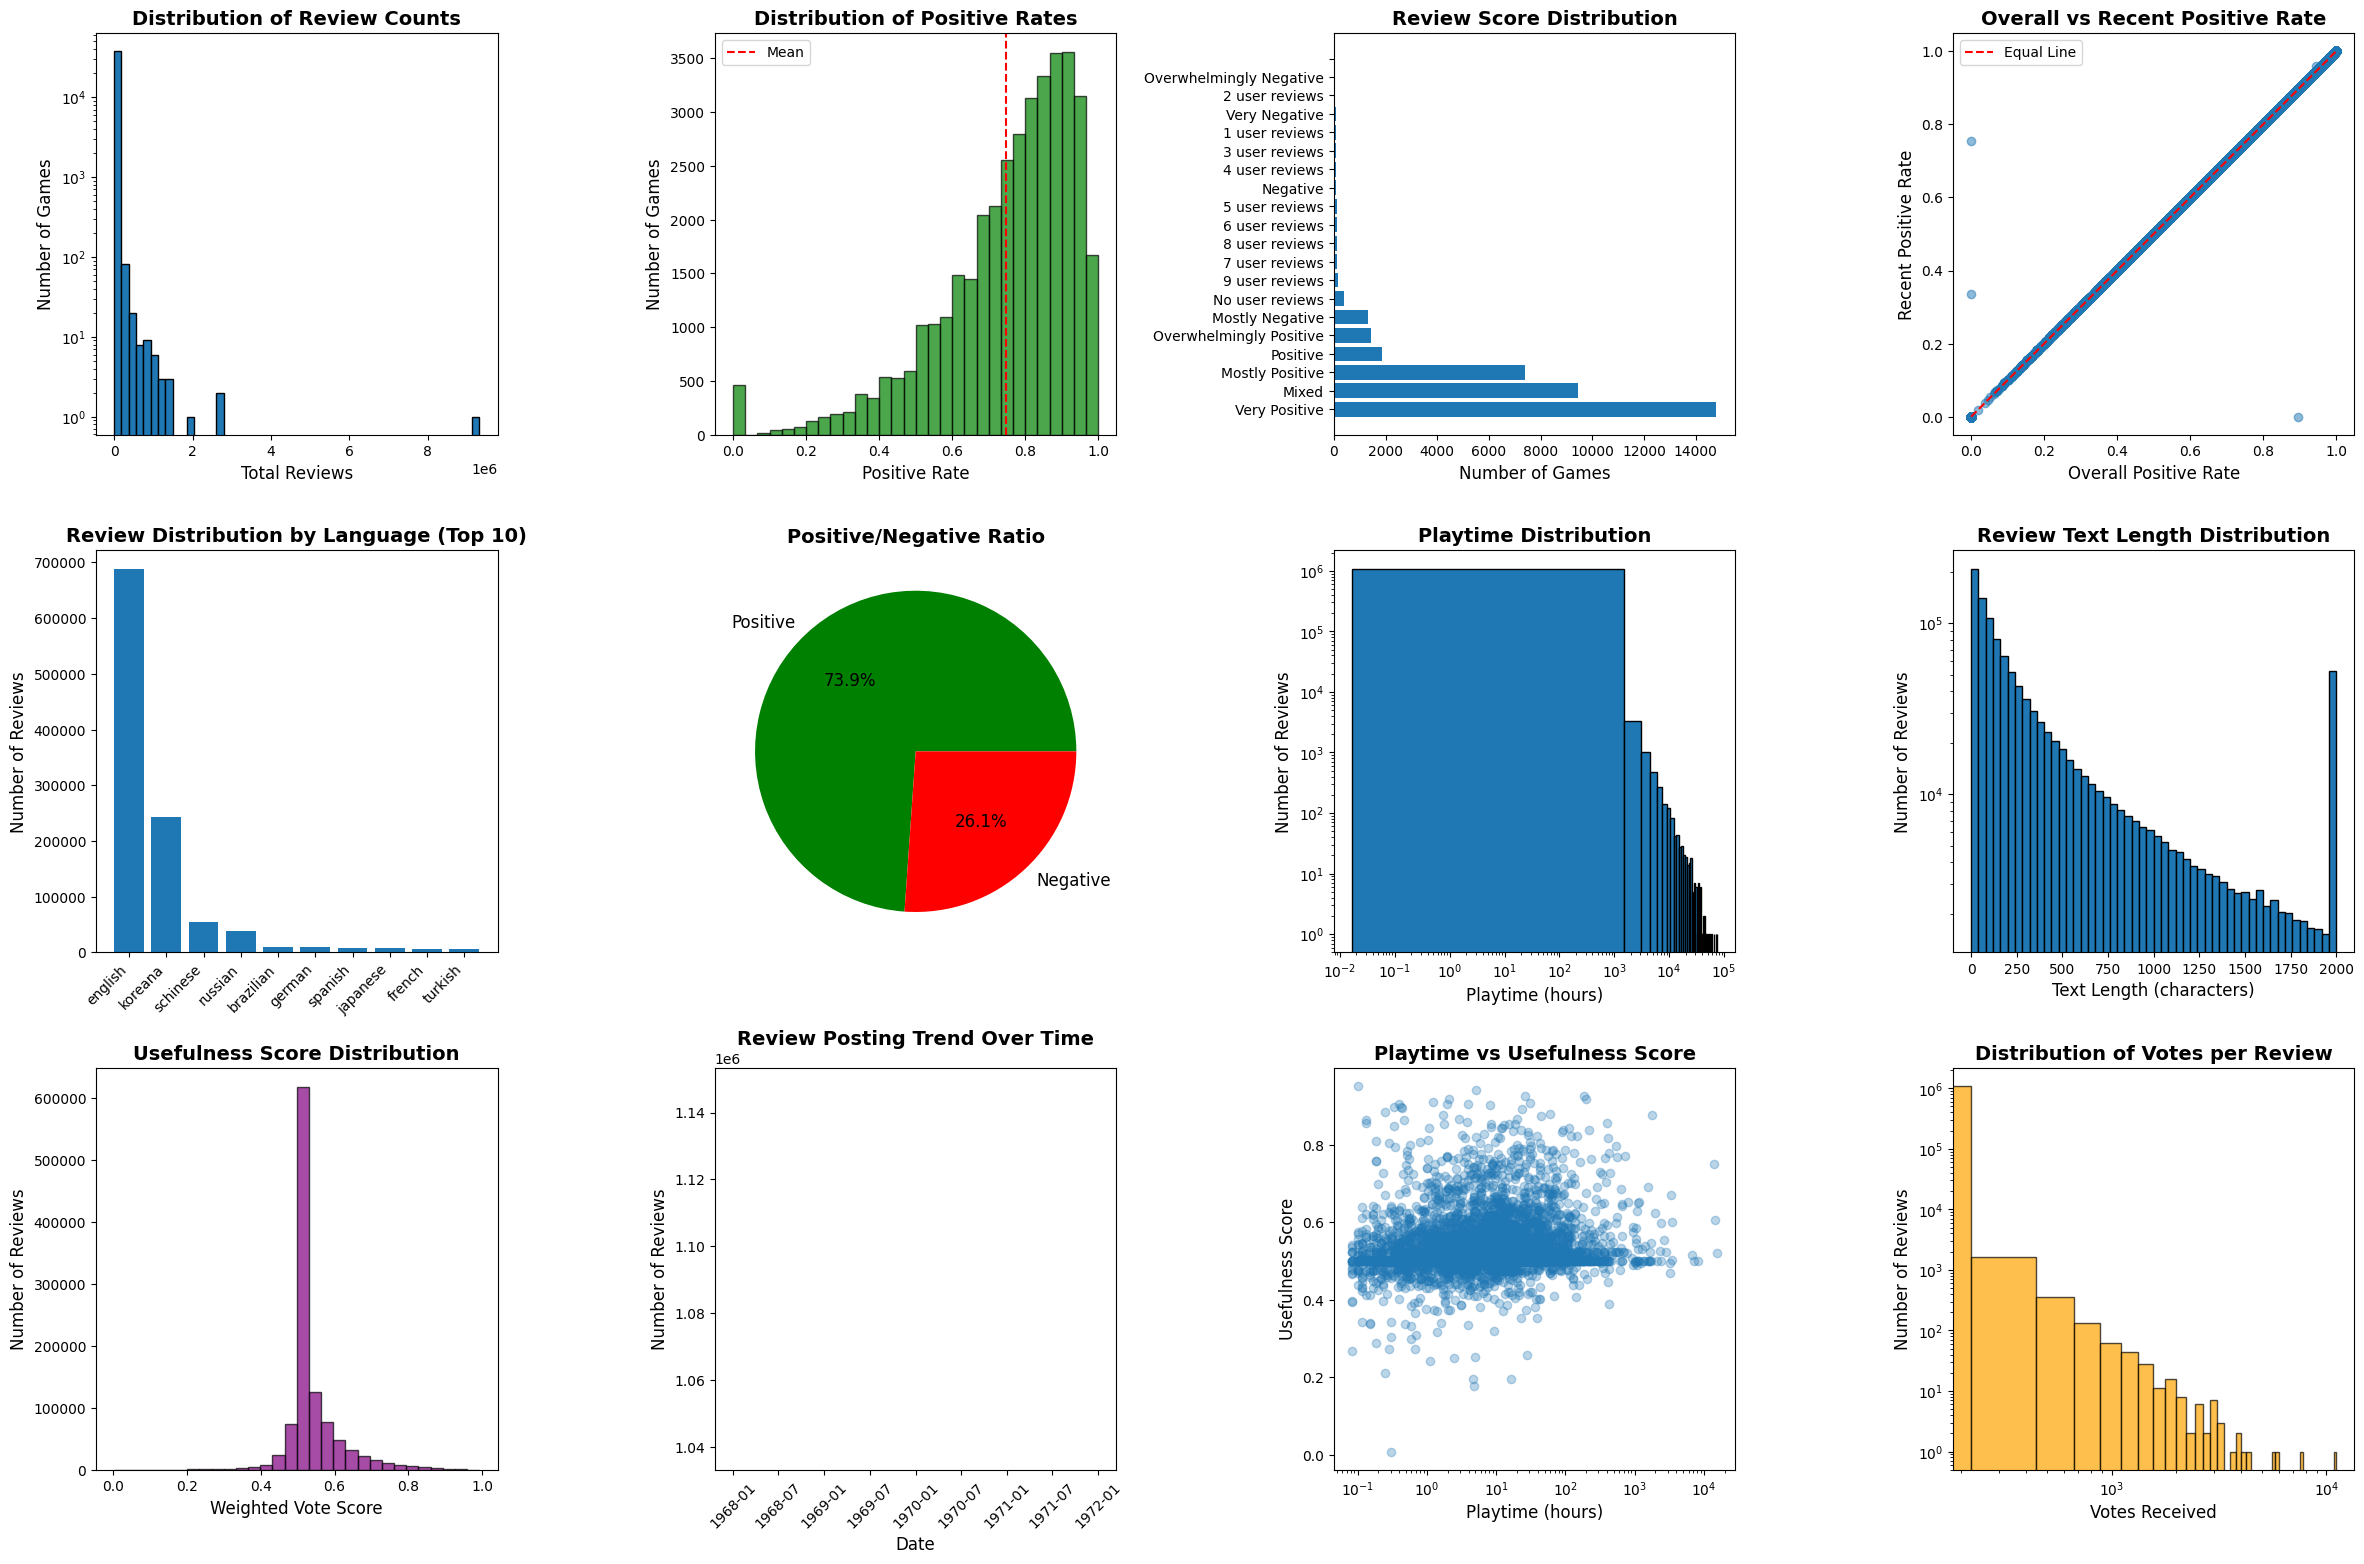

In [2]:
# ============================================
# 4. 시각화
# ============================================

def create_visualizations(df_stats, df_reviews):
    """주요 통계 시각화"""
    
    # 폰트 경고 완전히 제거
    import matplotlib
    matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
    
    fig = plt.figure(figsize=(24, 16))  # 크기 증가: 20x12 → 24x16
    
    # 1. 리뷰 수 분포
    plt.subplot(3, 4, 1)
    plt.hist(df_stats['total_reviews'], bins=50, edgecolor='black')
    plt.xlabel('Total Reviews', fontsize=12)
    plt.ylabel('Number of Games', fontsize=12)
    plt.title('Distribution of Review Counts', fontsize=14, fontweight='bold')
    plt.yscale('log')
    plt.tick_params(labelsize=10)
    
    # 2. 긍정률 분포
    plt.subplot(3, 4, 2)
    plt.hist(df_stats['total_positive_rate'], bins=30, edgecolor='black', color='green', alpha=0.7)
    plt.xlabel('Positive Rate', fontsize=12)
    plt.ylabel('Number of Games', fontsize=12)
    plt.title('Distribution of Positive Rates', fontsize=14, fontweight='bold')
    plt.axvline(df_stats['total_positive_rate'].mean(), color='red', linestyle='--', label='Mean')
    plt.legend(fontsize=10)
    plt.tick_params(labelsize=10)
    
    # 3. 평가 등급 분포
    plt.subplot(3, 4, 3)
    score_counts = df_stats['review_score'].value_counts()
    plt.barh(range(len(score_counts)), score_counts.values)
    plt.yticks(range(len(score_counts)), score_counts.index, fontsize=10)
    plt.xlabel('Number of Games', fontsize=12)
    plt.title('Review Score Distribution', fontsize=14, fontweight='bold')
    plt.tick_params(labelsize=10)
    
    # 4. 최근 vs 전체 긍정률 비교
    plt.subplot(3, 4, 4)
    plt.scatter(df_stats['total_positive_rate'], df_stats['recent_positive_rate'], alpha=0.5)
    plt.plot([0, 1], [0, 1], 'r--', label='Equal Line')
    plt.xlabel('Overall Positive Rate', fontsize=12)
    plt.ylabel('Recent Positive Rate', fontsize=12)
    plt.title('Overall vs Recent Positive Rate', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.tick_params(labelsize=10)
    
    # 5. 언어별 리뷰 분포
    plt.subplot(3, 4, 5)
    lang_counts = df_reviews['language'].value_counts().head(10)
    plt.bar(range(len(lang_counts)), lang_counts.values)
    plt.xticks(range(len(lang_counts)), lang_counts.index, rotation=45, ha='right', fontsize=10)
    plt.ylabel('Number of Reviews', fontsize=12)
    plt.title('Review Distribution by Language (Top 10)', fontsize=14, fontweight='bold')
    plt.tick_params(labelsize=10)
    
    # 6. 추천/비추천 분포
    plt.subplot(3, 4, 6)
    vote_counts = df_reviews['voted_up'].value_counts()
    plt.pie(vote_counts.values, labels=['Positive', 'Negative'], autopct='%1.1f%%', 
            colors=['green', 'red'], textprops={'fontsize': 12})
    plt.title('Positive/Negative Ratio', fontsize=14, fontweight='bold')
    
    # 7. 플레이타임 분포 (로그 스케일)
    plt.subplot(3, 4, 7)
    playtime_filtered = df_reviews[df_reviews['playtime_hours'] > 0]['playtime_hours']
    plt.hist(playtime_filtered, bins=50, edgecolor='black')
    plt.xlabel('Playtime (hours)', fontsize=12)
    plt.ylabel('Number of Reviews', fontsize=12)
    plt.title('Playtime Distribution', fontsize=14, fontweight='bold')
    plt.xscale('log')
    plt.yscale('log')
    plt.tick_params(labelsize=10)
    
    # 8. 리뷰 텍스트 길이 분포
    plt.subplot(3, 4, 8)
    plt.hist(df_reviews['text_length'], bins=50, edgecolor='black')
    plt.xlabel('Text Length (characters)', fontsize=12)
    plt.ylabel('Number of Reviews', fontsize=12)
    plt.title('Review Text Length Distribution', fontsize=14, fontweight='bold')
    plt.yscale('log')
    plt.tick_params(labelsize=10)
    
    # 9. 유용함 점수 분포
    plt.subplot(3, 4, 9)
    plt.hist(df_reviews['weighted_score'], bins=30, edgecolor='black', color='purple', alpha=0.7)
    plt.xlabel('Weighted Vote Score', fontsize=12)
    plt.ylabel('Number of Reviews', fontsize=12)
    plt.title('Usefulness Score Distribution', fontsize=14, fontweight='bold')
    plt.tick_params(labelsize=10)
    
    # 10. 시간별 리뷰 작성 추이
    plt.subplot(3, 4, 10)
    df_reviews['year_month'] = df_reviews['date'].dt.to_period('M')
    reviews_over_time = df_reviews.groupby('year_month').size()
    plt.plot(reviews_over_time.index.to_timestamp(), reviews_over_time.values, linewidth=2)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Reviews', fontsize=12)
    plt.title('Review Posting Trend Over Time', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, fontsize=10)
    plt.tick_params(labelsize=10)
    
    # 11. 플레이타임 vs 유용함 점수
    plt.subplot(3, 4, 11)
    sample = df_reviews.sample(min(5000, len(df_reviews)))
    plt.scatter(sample['playtime_hours'], sample['weighted_score'], alpha=0.3)
    plt.xlabel('Playtime (hours)', fontsize=12)
    plt.ylabel('Usefulness Score', fontsize=12)
    plt.title('Playtime vs Usefulness Score', fontsize=14, fontweight='bold')
    plt.xscale('log')
    plt.tick_params(labelsize=10)
    
    # 12. 추천 받은 수 분포
    plt.subplot(3, 4, 12)
    plt.hist(df_reviews['votes_up'], bins=50, edgecolor='black', color='orange', alpha=0.7)
    plt.xlabel('Votes Received', fontsize=12)
    plt.ylabel('Number of Reviews', fontsize=12)
    plt.title('Distribution of Votes per Review', fontsize=14, fontweight='bold')
    plt.xscale('log')
    plt.yscale('log')
    plt.tick_params(labelsize=10)
    
    plt.tight_layout(pad=2.0)  # 여백 증가
    plt.savefig('steam_reviews_eda.png', dpi=300, bbox_inches='tight')
    print("\n시각화 저장 완료: steam_reviews_eda.png")
    plt.show()

create_visualizations(df_stats, df_reviews)

In [3]:
# ============================================
# 5. 품질 필터링 분석
# ============================================

def quality_filtering_analysis(df_reviews):
    """RAG에 사용할 고품질 리뷰 필터링 분석"""
    
    print("\n=== 품질 필터링 분석 ===")
    
    # 다양한 필터 조건 테스트
    filters = {
        '원본': len(df_reviews),
        '플레이타임 1시간 이상': len(df_reviews[df_reviews['playtime_hours'] >= 1]),
        '플레이타임 5시간 이상': len(df_reviews[df_reviews['playtime_hours'] >= 5]),
        '텍스트 100자 이상': len(df_reviews[df_reviews['text_length'] >= 100]),
        '텍스트 200자 이상': len(df_reviews[df_reviews['text_length'] >= 200]),
        '유용함 점수 0.3 이상': len(df_reviews[df_reviews['weighted_score'] >= 0.3]),
        '유용함 점수 0.5 이상': len(df_reviews[df_reviews['weighted_score'] >= 0.5]),
    }
    
    for name, count in filters.items():
        percentage = (count / len(df_reviews)) * 100
        print(f"{name}: {count:,}개 ({percentage:.1f}%)")
    
    # 복합 필터 (RAG 권장)
    high_quality = df_reviews[
        (df_reviews['playtime_hours'] >= 1) &
        (df_reviews['text_length'] >= 100) &
        (df_reviews['weighted_score'] >= 0.3)
    ]
    
    print(f"\n고품질 리뷰 (플레이 1시간+, 100자+, 유용함 0.3+):")
    print(f"  - 개수: {len(high_quality):,}개 ({len(high_quality)/len(df_reviews)*100:.1f}%)")
    print(f"  - 평균 플레이타임: {high_quality['playtime_hours'].mean():.1f}시간")
    print(f"  - 평균 텍스트 길이: {high_quality['text_length'].mean():.0f}자")
    print(f"  - 평균 유용함 점수: {high_quality['weighted_score'].mean():.3f}")
    
    return high_quality

df_high_quality = quality_filtering_analysis(df_reviews)

# ============================================
# 6. 언어별 분석
# ============================================

def language_analysis(df_reviews):
    """언어별 리뷰 품질 분석"""
    
    print("\n=== 언어별 분석 ===")
    
    lang_stats = df_reviews.groupby('language').agg({
        'review_id': 'count',
        'voted_up': 'mean',
        'playtime_hours': 'mean',
        'text_length': 'mean',
        'weighted_score': 'mean'
    }).round(2)
    
    lang_stats.columns = ['리뷰 수', '긍정률', '평균 플레이타임', '평균 텍스트 길이', '평균 유용함 점수']
    lang_stats = lang_stats.sort_values('리뷰 수', ascending=False).head(10)
    
    print(lang_stats)
    
    # 한국어 vs 영어 비교
    korean_reviews = df_reviews[df_reviews['language'] == 'koreana']
    english_reviews = df_reviews[df_reviews['language'] == 'english']
    
    print(f"\n한국어 리뷰: {len(korean_reviews):,}개")
    print(f"  - 긍정률: {korean_reviews['voted_up'].mean():.3f}")
    print(f"  - 평균 플레이타임: {korean_reviews['playtime_hours'].mean():.1f}시간")
    
    print(f"\n영어 리뷰: {len(english_reviews):,}개")
    print(f"  - 긍정률: {english_reviews['voted_up'].mean():.3f}")
    print(f"  - 평균 플레이타임: {english_reviews['playtime_hours'].mean():.1f}시간")

language_analysis(df_reviews)

# ============================================
# 7. 게임별 Top/Bottom 분석
# ============================================

def top_bottom_games(df_stats):
    """가장 좋은/나쁜 평가를 받은 게임 분석"""
    
    print("\n=== Top 10 게임 (긍정률 기준, 리뷰 100개 이상) ===")
    top_games = df_stats[df_stats['total_reviews'] >= 100].nlargest(10, 'total_positive_rate')
    print(top_games[['appid', 'total_reviews', 'total_positive_rate', 'review_score']].to_string(index=False))
    
    print("\n=== Bottom 10 게임 (긍정률 기준, 리뷰 100개 이상) ===")
    bottom_games = df_stats[df_stats['total_reviews'] >= 100].nsmallest(10, 'total_positive_rate')
    print(bottom_games[['appid', 'total_reviews', 'total_positive_rate', 'review_score']].to_string(index=False))
    
    print("\n=== 최다 리뷰 게임 Top 10 ===")
    most_reviewed = df_stats.nlargest(10, 'total_reviews')
    print(most_reviewed[['appid', 'total_reviews', 'total_positive_rate', 'review_score']].to_string(index=False))

top_bottom_games(df_stats)


=== 품질 필터링 분석 ===
원본: 1,093,286개 (100.0%)
플레이타임 1시간 이상: 914,027개 (83.6%)
플레이타임 5시간 이상: 605,092개 (55.3%)
텍스트 100자 이상: 687,768개 (62.9%)
텍스트 200자 이상: 492,431개 (45.0%)
유용함 점수 0.3 이상: 1,090,134개 (99.7%)
유용함 점수 0.5 이상: 970,212개 (88.7%)

고품질 리뷰 (플레이 1시간+, 100자+, 유용함 0.3+):
  - 개수: 586,194개 (53.6%)
  - 평균 플레이타임: 63.0시간
  - 평균 텍스트 길이: 601자
  - 평균 유용함 점수: 0.552

=== 언어별 분석 ===
             리뷰 수   긍정률  평균 플레이타임  평균 텍스트 길이  평균 유용함 점수
language                                               
english    687497  0.73     54.30     476.17       0.54
koreana    243334  0.76     67.86     171.64       0.52
schinese    55338  0.74     37.27     208.46       0.53
russian     38806  0.73     26.17     360.35       0.52
brazilian    9734  0.78     28.21     325.29       0.52
german       9133  0.70     27.82     391.05       0.53
spanish      8156  0.75     28.37     338.90       0.51
japanese     7571  0.75     60.66     316.68       0.53
french       6888  0.68     34.89     390.99       0.51
turkish      

In [5]:
import json, re, math
from hashlib import sha1

# --------- 설정값 ---------
INPUT = "/data/ephemeral/home/T8161/game_data/extracted/steam_reviews.jsonl"
OUTPUT = "/data/ephemeral/home/T8161/game_data/extracted/steam_review_sents_ko.jsonl"

ALLOWED_LANGS = {"koreana"}   # 필요하면 {"koreana","english"}
MIN_REVIEW_LEN = 30          # 리뷰 기준 최소 길이
MIN_SENT_LEN = 20            # 문장 최소 길이
MAX_SENT_LEN = 200           # 문장 최대 길이

# 문장 분할: ., !, ?, 줄바꿈 + 일부 구분자
SENT_SPLIT_RE = re.compile(r'(?<=[\.\!\?\n])\s+|[\n\r]+|(?<=\.)|(?<=\!)|(?<=\?)')

# 도배/의미없는 짧은 문장 패턴
LOW_INFO_RE = re.compile(r'^(ㅋ+|ㅎ+|ㅠ+|ㅜ+|ㅇ+|ㄷ+|굿+|갓겜+|노잼+|재밌+|별로+|추천+|비추+|good+|bad+)$', re.IGNORECASE)

# 반복문자 축약 (ex: ㅋㅋㅋㅋㅋㅋ -> ㅋㅋ)
REPEAT_CHAR_RE = re.compile(r'(.)\1{3,}')  # 4번 이상 반복 -> 축약


def normalize_text(t: str) -> str:
    if not t:
        return ""
    t = t.strip()
    # 긴 반복 문자 줄이기
    t = REPEAT_CHAR_RE.sub(r'\1\1', t)
    # 공백 정리
    t = re.sub(r'\s+', ' ', t).strip()
    return t


def content_ratio_ok(s: str) -> bool:
    """한글/영문/숫자가 너무 적은 문장 제거."""
    if not s:
        return False
    total = len(s)
    meaningful = sum(ch.isalnum() or ('가' <= ch <= '힣') for ch in s)
    return (meaningful / total) >= 0.35  # 필요시 조정


def playtime_factor(playtime_min: int) -> float:
    if playtime_min is None:
        return 1.0
    if playtime_min < 30:
        return 0.6
    if playtime_min < 120:
        return 1.0
    return 1.3


def quality_score(votes_up: int, wvs: float, playtime_min: int) -> float:
    votes_up = votes_up or 0
    wvs = wvs if (wvs is not None and wvs > 0) else 0.1
    return math.log1p(votes_up) * wvs * playtime_factor(playtime_min)


def split_sentences(text: str):
    # 1차 분할
    parts = re.split(r'[\n]+', text)
    sents = []
    for p in parts:
        p = p.strip()
        if not p:
            continue
        # 2차 분할 (문장부호 기준)
        chunks = re.split(r'(?<=[\.\!\?])\s+', p)
        for c in chunks:
            c = c.strip()
            if c:
                sents.append(c)
    return sents


def is_low_info_sentence(s: str) -> bool:
    # 너무 짧고 의미 없는 것 방지
    s2 = re.sub(r'\s+', '', s)
    return bool(LOW_INFO_RE.match(s2))


# ----- 중복 제거용 해시 집합(메모리 아끼려면 appid별로 리셋하거나 bloom filter 사용) -----
seen_sent_hash = set()

with open(INPUT, "r", encoding="utf-8") as fin, open(OUTPUT, "w", encoding="utf-8") as fout:
    for line in fin:
        line = line.strip()
        if not line:
            continue
        obj = json.loads(line)

        appid = int(obj["appid"])
        reviews = obj.get("reviews", [])

        for r in reviews:
            lang = r.get("language")
            if lang not in ALLOWED_LANGS:
                continue

            text = normalize_text(r.get("text", ""))
            if len(text) < MIN_REVIEW_LEN:
                continue

            review_id = str(r.get("id", ""))
            voted_up = bool(r.get("voted_up", False))
            label = 1 if voted_up else 0

            votes_up = int(r.get("votes_up") or 0)
            wvs = r.get("weighted_vote_score")
            wvs = float(wvs) if wvs is not None else None
            playtime_min = r.get("playtime")
            playtime_min = int(playtime_min) if playtime_min is not None else None
            date = r.get("date")

            q = quality_score(votes_up, wvs, playtime_min)

            # 문장 분리
            for sent in split_sentences(text):
                sent = normalize_text(sent)

                if not (MIN_SENT_LEN <= len(sent) <= MAX_SENT_LEN):
                    continue
                if is_low_info_sentence(sent):
                    continue
                if not content_ratio_ok(sent):
                    continue

                # 유사 중복의 최소 버전: 공백/구두점 제거 후 해시
                dedup_key = re.sub(r'[\s\W_]+', '', sent.lower())
                h = sha1(dedup_key.encode("utf-8")).hexdigest()
                if h in seen_sent_hash:
                    continue
                seen_sent_hash.add(h)

                out = {
                    "appid": appid,
                    "review_id": review_id,
                    "lang": lang,
                    "sent": sent,
                    "label": label,
                    "quality": round(q, 4),
                    "votes_up": votes_up,
                    "wvs": wvs,
                    "playtime_min": playtime_min,
                    "date": date
                }
                fout.write(json.dumps(out, ensure_ascii=False) + "\n")

print("done ->", OUTPUT)


done -> /data/ephemeral/home/T8161/game_data/extracted/steam_review_sents_ko.jsonl


📂 파일 로딩 중: /data/ephemeral/home/T8161/game_data/extracted/steam_review_sents_ko.jsonl
✅ 584,467개의 레코드 로드 완료

📊 Steam 게임 리뷰 데이터 EDA

1️⃣ 데이터 기본 정보
----------------------------------------------------------------------------------------------------
총 문장 수: 584,467개
고유 리뷰 ID 수: 165,201개
고유 게임(AppID) 수: 22,991개
언어: ['koreana']
분석 기간: 2010-11-28 ~ 2026-01-20

데이터프레임 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584467 entries, 0 to 584466
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   appid           584467 non-null  int64         
 1   review_id       584467 non-null  object        
 2   lang            584467 non-null  object        
 3   sent            584467 non-null  object        
 4   label           584467 non-null  int64         
 5   quality         584467 non-null  float64       
 6   votes_up        584467 non-null  int64         
 7   wvs             584467 non-null  float6

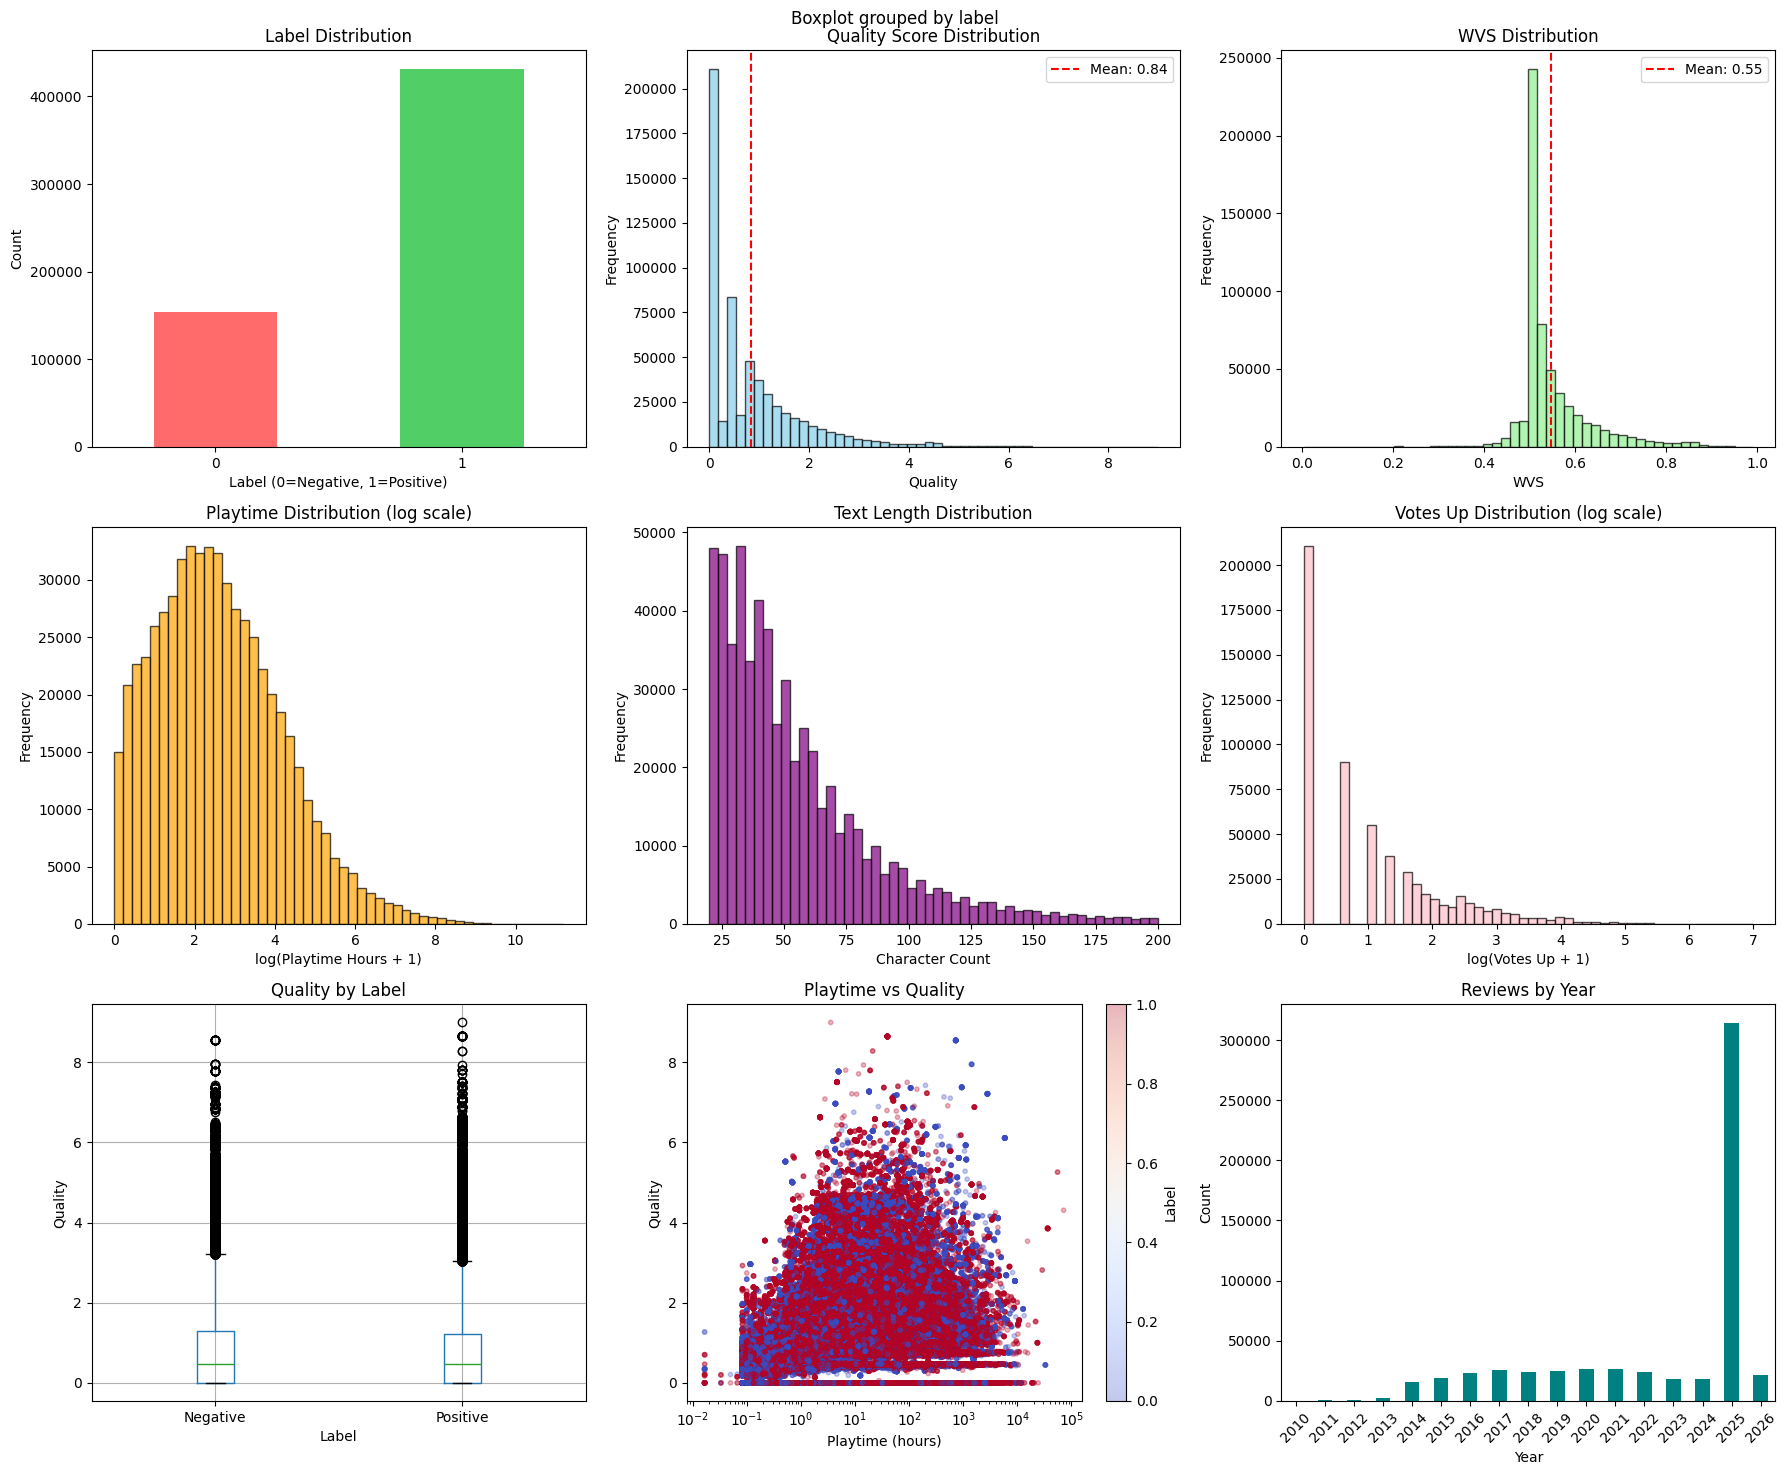

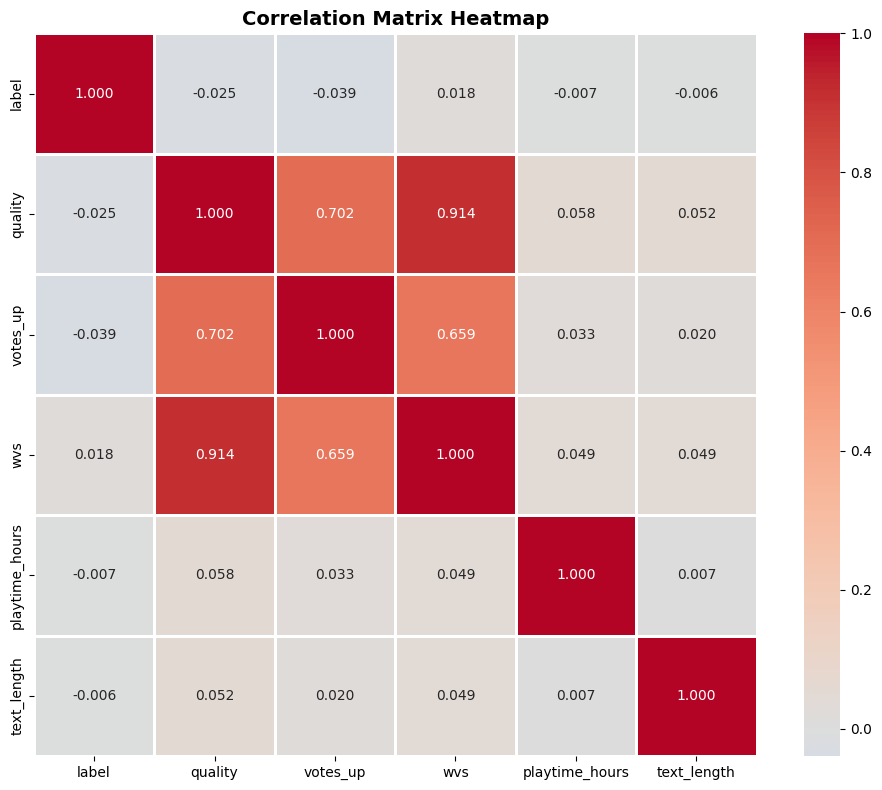

In [12]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
from collections import Counter
import re

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

def load_jsonl(file_path):
    """JSONL 파일 로드"""
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return pd.DataFrame(data)

def perform_eda(df, output_dir='/data/ephemeral/home/T8161/game_data'):
    """전체 EDA 수행"""
    
    print("="*100)
    print("📊 Steam 게임 리뷰 데이터 EDA")
    print("="*100)
    
    # 날짜 변환
    df['datetime'] = pd.to_datetime(df['date'], unit='s')
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['date_str'] = df['datetime'].dt.strftime('%Y-%m-%d')
    
    # 텍스트 길이 계산
    df['text_length'] = df['sent'].apply(len)
    df['word_count'] = df['sent'].apply(lambda x: len(x.split()))
    
    # 플레이 타임 (시간 단위)
    df['playtime_hours'] = df['playtime_min'] / 60
    
    # ============================================================================
    # 1. 기본 정보
    # ============================================================================
    print("\n1️⃣ 데이터 기본 정보")
    print("-"*100)
    print(f"총 문장 수: {len(df):,}개")
    print(f"고유 리뷰 ID 수: {df['review_id'].nunique():,}개")
    print(f"고유 게임(AppID) 수: {df['appid'].nunique():,}개")
    print(f"언어: {df['lang'].unique()}")
    print(f"분석 기간: {df['date_str'].min()} ~ {df['date_str'].max()}")
    print(f"\n데이터프레임 정보:")
    print(df.info())
    
    # ============================================================================
    # 2. 레이블 분포
    # ============================================================================
    print("\n2️⃣ 레이블 분포")
    print("-"*100)
    label_counts = df['label'].value_counts().sort_index()
    print(label_counts)
    print(f"\n긍정(1) 비율: {(df['label'] == 1).sum() / len(df) * 100:.2f}%")
    print(f"부정(0) 비율: {(df['label'] == 0).sum() / len(df) * 100:.2f}%")
    
    # ============================================================================
    # 3. 통계 요약
    # ============================================================================
    print("\n3️⃣ 수치형 변수 통계 요약")
    print("-"*100)
    numeric_cols = ['quality', 'votes_up', 'wvs', 'playtime_min', 'playtime_hours', 'text_length', 'word_count']
    print(df[numeric_cols].describe())
    
    # ============================================================================
    # 4. 게임별 분석
    # ============================================================================
    print("\n4️⃣ 게임(AppID)별 통계")
    print("-"*100)
    game_stats = df.groupby('appid').agg({
        'review_id': 'count',
        'label': 'mean',
        'quality': 'mean',
        'votes_up': 'mean',
        'playtime_hours': 'mean'
    }).round(2)
    game_stats.columns = ['리뷰_수', '긍정_비율', '평균_품질', '평균_추천수', '평균_플레이타임(시간)']
    game_stats = game_stats.sort_values('리뷰_수', ascending=False)
    print(game_stats.head(20))
    
    # ============================================================================
    # 5. 플레이 타임 분석
    # ============================================================================
    print("\n5️⃣ 플레이 타임 분석")
    print("-"*100)
    print(f"평균 플레이 타임: {df['playtime_hours'].mean():.2f}시간")
    print(f"중간값: {df['playtime_hours'].median():.2f}시간")
    print(f"최소: {df['playtime_hours'].min():.2f}시간")
    print(f"최대: {df['playtime_hours'].max():.2f}시간")
    print(f"표준편차: {df['playtime_hours'].std():.2f}시간")
    
    # 플레이 타임 구간별 분포
    playtime_bins = [0, 10, 50, 100, 500, 1000, float('inf')]
    playtime_labels = ['0-10h', '10-50h', '50-100h', '100-500h', '500-1000h', '1000h+']
    df['playtime_category'] = pd.cut(df['playtime_hours'], bins=playtime_bins, labels=playtime_labels)
    print("\n플레이 타임 구간별 분포:")
    print(df['playtime_category'].value_counts().sort_index())
    
    # ============================================================================
    # 6. 품질 지표 분석
    # ============================================================================
    print("\n6️⃣ 품질 지표 분석")
    print("-"*100)
    print(f"평균 Quality: {df['quality'].mean():.4f}")
    print(f"평균 WVS: {df['wvs'].mean():.4f}")
    print(f"평균 추천 수(votes_up): {df['votes_up'].mean():.2f}")
    
    # 품질 구간별 분포
    quality_bins = [0, 1, 2, 3, 4, 5, float('inf')]
    quality_labels = ['0-1', '1-2', '2-3', '3-4', '4-5', '5+']
    df['quality_category'] = pd.cut(df['quality'], bins=quality_bins, labels=quality_labels)
    print("\nQuality 점수 구간별 분포:")
    print(df['quality_category'].value_counts().sort_index())
    
    # ============================================================================
    # 7. 텍스트 길이 분석
    # ============================================================================
    print("\n7️⃣ 텍스트 길이 분석")
    print("-"*100)
    print(f"평균 문장 길이: {df['text_length'].mean():.2f}자")
    print(f"평균 단어 수: {df['word_count'].mean():.2f}개")
    print(f"최소 길이: {df['text_length'].min()}자")
    print(f"최대 길이: {df['text_length'].max()}자")
    
    # ============================================================================
    # 8. 시계열 분석
    # ============================================================================
    print("\n8️⃣ 시계열 분석 (연도별)")
    print("-"*100)
    yearly_stats = df.groupby('year').agg({
        'review_id': 'count',
        'label': 'mean',
        'quality': 'mean'
    }).round(3)
    yearly_stats.columns = ['리뷰_수', '긍정_비율', '평균_품질']
    print(yearly_stats)
    
    # ============================================================================
    # 9. 상관관계 분석
    # ============================================================================
    print("\n9️⃣ 상관관계 분석")
    print("-"*100)
    correlation_cols = ['label', 'quality', 'votes_up', 'wvs', 'playtime_hours', 'text_length']
    correlation_matrix = df[correlation_cols].corr()
    print(correlation_matrix.round(3))
    
    # ============================================================================
    # 10. 레이블별 비교
    # ============================================================================
    print("\n🔟 레이블별 비교 (긍정 vs 부정)")
    print("-"*100)
    label_comparison = df.groupby('label').agg({
        'quality': 'mean',
        'votes_up': 'mean',
        'wvs': 'mean',
        'playtime_hours': 'mean',
        'text_length': 'mean',
        'word_count': 'mean'
    }).round(2)
    label_comparison.columns = ['평균_품질', '평균_추천수', '평균_WVS', '평균_플레이타임', '평균_문장길이', '평균_단어수']
    print(label_comparison)
    
    # ============================================================================
    # 11. 샘플 리뷰 출력
    # ============================================================================
    print("\n1️⃣1️⃣ 샘플 리뷰")
    print("-"*100)
    print("\n[긍정 리뷰 샘플 - 높은 품질]")
    positive_high_quality = df[df['label'] == 1].nlargest(3, 'quality')
    for idx, row in positive_high_quality.iterrows():
        print(f"\n품질: {row['quality']:.4f} | 추천: {row['votes_up']} | 플레이타임: {row['playtime_hours']:.1f}h")
        print(f"내용: {row['sent'][:150]}...")
    
    print("\n[부정 리뷰 샘플 - 높은 품질]")
    negative_high_quality = df[df['label'] == 0].nlargest(3, 'quality')
    for idx, row in negative_high_quality.iterrows():
        print(f"\n품질: {row['quality']:.4f} | 추천: {row['votes_up']} | 플레이타임: {row['playtime_hours']:.1f}h")
        print(f"내용: {row['sent'][:150]}...")
    
    # ============================================================================
    # 12. 시각화
    # ============================================================================
    print("\n1️⃣2️⃣ 시각화 생성 중...")
    print("-"*100)
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle('Steam Review Data EDA', fontsize=16, fontweight='bold')
    
    # 1. 레이블 분포
    ax = axes[0, 0]
    label_counts.plot(kind='bar', ax=ax, color=['#ff6b6b', '#51cf66'])
    ax.set_title('Label Distribution')
    ax.set_xlabel('Label (0=Negative, 1=Positive)')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
    
    # 2. Quality 분포
    ax = axes[0, 1]
    ax.hist(df['quality'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title('Quality Score Distribution')
    ax.set_xlabel('Quality')
    ax.set_ylabel('Frequency')
    ax.axvline(df['quality'].mean(), color='red', linestyle='--', label=f'Mean: {df["quality"].mean():.2f}')
    ax.legend()
    
    # 3. WVS 분포
    ax = axes[0, 2]
    ax.hist(df['wvs'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    ax.set_title('WVS Distribution')
    ax.set_xlabel('WVS')
    ax.set_ylabel('Frequency')
    ax.axvline(df['wvs'].mean(), color='red', linestyle='--', label=f'Mean: {df["wvs"].mean():.2f}')
    ax.legend()
    
    # 4. 플레이 타임 분포 (로그 스케일)
    ax = axes[1, 0]
    ax.hist(np.log1p(df['playtime_hours']), bins=50, color='orange', edgecolor='black', alpha=0.7)
    ax.set_title('Playtime Distribution (log scale)')
    ax.set_xlabel('log(Playtime Hours + 1)')
    ax.set_ylabel('Frequency')
    
    # 5. 텍스트 길이 분포
    ax = axes[1, 1]
    ax.hist(df['text_length'], bins=50, color='purple', edgecolor='black', alpha=0.7)
    ax.set_title('Text Length Distribution')
    ax.set_xlabel('Character Count')
    ax.set_ylabel('Frequency')
    
    # 6. Votes Up 분포 (로그 스케일)
    ax = axes[1, 2]
    ax.hist(np.log1p(df['votes_up']), bins=50, color='pink', edgecolor='black', alpha=0.7)
    ax.set_title('Votes Up Distribution (log scale)')
    ax.set_xlabel('log(Votes Up + 1)')
    ax.set_ylabel('Frequency')
    
    # 7. Quality vs Label
    ax = axes[2, 0]
    df.boxplot(column='quality', by='label', ax=ax)
    ax.set_title('Quality by Label')
    ax.set_xlabel('Label')
    ax.set_ylabel('Quality')
    plt.sca(ax)
    plt.xticks([1, 2], ['Negative', 'Positive'])
    
    # 8. Playtime vs Quality (산점도)
    ax = axes[2, 1]
    scatter = ax.scatter(df['playtime_hours'], df['quality'], 
                        c=df['label'], cmap='coolwarm', alpha=0.3, s=10)
    ax.set_title('Playtime vs Quality')
    ax.set_xlabel('Playtime (hours)')
    ax.set_ylabel('Quality')
    ax.set_xscale('log')
    plt.colorbar(scatter, ax=ax, label='Label')
    
    # 9. 연도별 리뷰 수
    ax = axes[2, 2]
    yearly_counts = df['year'].value_counts().sort_index()
    yearly_counts.plot(kind='bar', ax=ax, color='teal')
    ax.set_title('Reviews by Year')
    ax.set_xlabel('Year')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/steam_review_eda.png', dpi=300, bbox_inches='tight')
    print(f"시각화 저장 완료: {output_dir}/steam_review_eda.png")
    
    # ============================================================================
    # 추가 시각화 2 - 상관관계 히트맵
    # ============================================================================
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
                center=0, square=True, linewidths=1)
    plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/correlation_heatmap.png', dpi=300, bbox_inches='tight')
    print(f"상관관계 히트맵 저장 완료: {output_dir}/correlation_heatmap.png")
    
    print("\n" + "="*100)
    print("✅ EDA 완료!")
    print("="*100)
    
    return df

# 메인 실행
if __name__ == "__main__":
    # 파일 경로 지정
    file_path = "/data/ephemeral/home/T8161/game_data/extracted/steam_review_sents_ko.jsonl"
    
    # 파일이 있는지 확인
    import os
    if not os.path.exists(file_path):
        print(f"❌ 파일을 찾을 수 없습니다: {file_path}")
        print("파일 경로를 확인하거나 파일을 업로드해주세요.")
    else:
        print(f"📂 파일 로딩 중: {file_path}")
        df = load_jsonl(file_path)
        print(f"✅ {len(df):,}개의 레코드 로드 완료\n")
        
        # EDA 수행
        df_analyzed = perform_eda(df)